In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [ ]:
n = 1000

gelir = np.random.lognormal(mean=10.5, sigma=0.6, size=n)
memnuniyet = np.random.choice([1, 2, 3, 4, 5], size=n, p=[0.05, 0.1, 0.2, 0.35, 0.3])
gurultu = np.random.normal(0, 80, n)

aylik_harcama = (0.004 * gelir + 15 * memnuniyet + gurultu).clip(min=10)

df = pd.DataFrame({
    "musteri_id": range(1, n + 1),
    "yas": np.random.normal(38, 12, n).round(0),
    "gelir": gelir.round(2),
    "sehir": np.random.choice(
        ["İstanbul", "Ankara", "İzmir", "Bursa", "istanbul", "ANKARA"],
        size=n, p=[0.35, 0.2, 0.15, 0.1, 0.1, 0.1]
    ),
    "abonelik_tipi": np.random.choice(["Temel", "Standart", "Premium"], size=n, p=[0.5, 0.35, 0.15]),
    "aylik_harcama": aylik_harcama.round(2),
    "memnuniyet_puani": memnuniyet.astype(float),
    "churn": np.random.choice([0, 1], size=n, p=[0.8, 0.2]),
})

# Kasıtlı bozulmalar
df.loc[df.sample(frac=0.08, random_state=1).index, "gelir"] = np.nan
df.loc[df.sample(frac=0.05, random_state=2).index, "yas"] = np.nan
outlier_idx = df.sample(frac=0.01, random_state=4).index
df.loc[outlier_idx, "gelir"] = df["gelir"].max() * np.random.uniform(3, 6, len(outlier_idx))
df = pd.concat([df, df.sample(5, random_state=7)], ignore_index=True)

sayisal_sutunlar = ["yas", "gelir", "aylik_harcama", "memnuniyet_puani"]
kategorik_sutunlar = ["sehir", "abonelik_tipi", "churn"]

print(f"Veri seti: {df.shape[0]} satır, {df.shape[1]} sütun")
df.head()


Veri seti: 1005 satır, 8 sütun


,musteri_id,yas,gelir,sehir,abonelik_tipi,aylik_harcama,memnuniyet_puani,churn
0,1,34.0,96524.43,Bursa,Standart,501.48,5.0,0
1,2,56.0,44810.17,ANKARA,Standart,464.23,4.0,0
2,3,25.0,55828.91,Ankara,Temel,383.08,4.0,0
3,4,42.0,13615.34,Bursa,Standart,10.00,4.0,0
4,5,28.0,40578.96,İstanbul,Standart,147.66,5.0,0


##  Genel Bakış Özet

In [ ]:
ozet = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "eksik_değer":df.isnull().sum(),
    "eksik_değer_yüzdesi":(df.isnull().mean()*100).round(2)
})

ozet

,dtype,n_unique,eksik_değer,eksik_değer_yüzdesi
musteri_id,int64,1000,0,0.00
yas,float64,67,50,4.98
gelir,float64,921,79,7.86
sehir,object,6,0,0.00
abonelik_tipi,object,3,0,0.00
aylik_harcama,float64,964,0,0.00
memnuniyet_puani,float64,5,0,0.00
churn,int64,2,0,0.00


In [ ]:
print("tekrar eden satır:", df.duplicated().sum())
df["sehir"] = df["sehir"].str.strip().str.title().replace({"Istanbul": "İstanbul"})
print(df["sehir"].value_counts())


tekrar eden satır: 5
sehir
İstanbul    484
Ankara      282
İzmir       146
Bursa        93
Name: count, dtype: int64


## **Betimsel İstatistik ve güven aralığı**

In [ ]:
def ortalama_guven_aralığı(seri,guven=0.95):
  veri = seri.dropna()
  n = len(veri)
  ortalama = veri.mean()
  sem = stats.sem(veri) # standart error of the mean
  t_kritik = stats.t.ppf((1+guven)/2 ,df =n-1)
  hata_payi = t_kritik*sem
  return ortalama,ortalama-hata_payi,ortalama+hata_payi

print(f"{'değişken':20s},{'Ortalama':>12s},{'%95 Alt':>12s},{'%95 Üst':>12s}")
for degisken in sayisal_sutunlar:
  ortalama,alt,ust = ortalama_guven_aralığı(df[degisken])
  print(f"{degisken:20s},{ortalama:>12.2f},{alt:>12.2f},{ust:>12.2f}")
#

değişken            ,    Ortalama,     %95 Alt,     %95 Üst
yas                 ,       38.03,       37.26,       38.79
gelir               ,    55655.91,    47361.55,    63950.28
aylik_harcama       ,      229.95,      221.49,      238.41
memnuniyet_puani    ,        3.76,        3.69,        3.83


In [ ]:
betimsel = df[sayisal_sutunlar].describe().T
betimsel["skew"] = df[sayisal_sutunlar].skew()
betimsel["kurtosis"] = df[sayisal_sutunlar].kurtosis()
betimsel.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
yas,955.0,38.03,12.05,5.00,30.50,38.00,46.00,75.00,-0.03,-0.03
gelir,926.0,55655.91,128609.17,5071.19,24017.86,37094.08,55305.24,1482341.05,9.25,89.20
aylik_harcama,1005.0,229.95,136.65,10.00,134.88,210.51,308.53,1110.30,1.12,3.10
memnuniyet_puani,1005.0,3.76,1.12,1.00,3.00,4.00,5.00,5.00,-0.77,-0.10


## **Normallik Testleri**

In [ ]:
print(f"{'Değişken':20s} {'Shapiro-Wilk p':>16s} {'DAgostino p'} Yorum ")
for col in sayisal_sutunlar:
  veri= df[col].dropna()
  # shapiro n> 5000 den fazla olursa güvenilmez olur
  ornek = veri.sample(min(len(veri),5000),random_state=0)
  sw_stat, sw_p = stats.shapiro(ornek)
  da_stat, da_p = stats.normaltest(veri)
  yorum = "Normal dağılım varsayımı sağlanmaktadır." if sw_p > 0.05 else "Normal dağılım varsayımı sağlanmamaktadır."
  print(f"{col:20s} {sw_p:>16.4f} {da_p:>16.4f} {yorum}")

Değişken               Shapiro-Wilk p DAgostino p Yorum 
yas                            0.0947           0.9098 Normal dağılım varsayımı sağlanmaktadır.
gelir                          0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
aylik_harcama                  0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
memnuniyet_puani               0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.


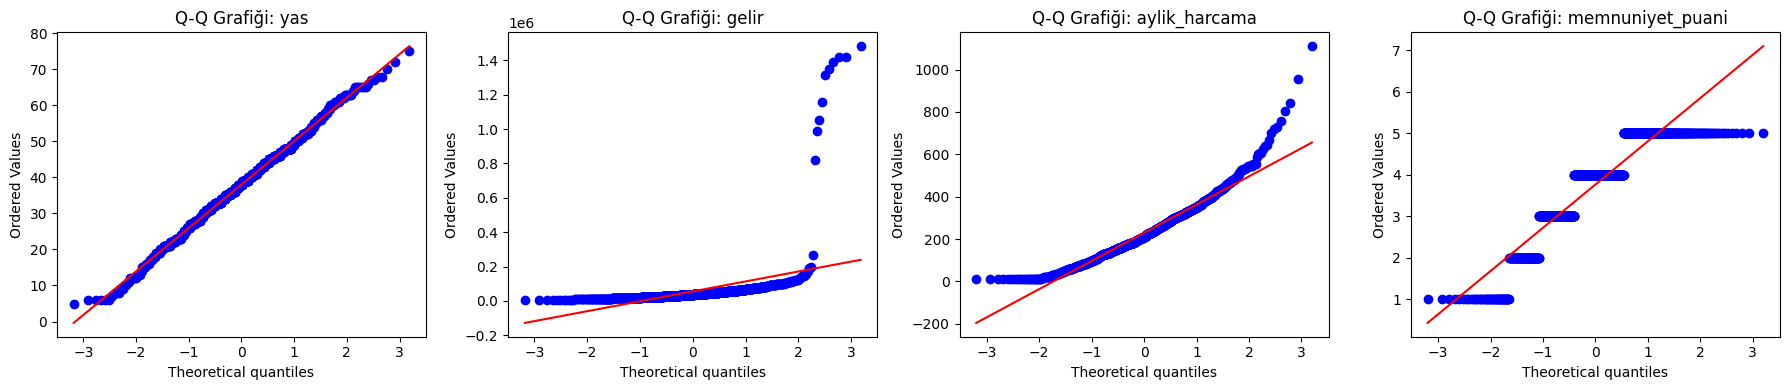

In [ ]:
fig, axes = plt.subplots(1, len(sayisal_sutunlar), figsize=(18, 4))
for ax, col in zip(axes, sayisal_sutunlar):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q Grafiği: {col}")
plt.tight_layout()
plt.show()

## **İki Grup Karşılaştırması**

In [ ]:
grup0= df.loc[df["churn"] == 0 , "aylik_harcama"].dropna()
grup1 = df.loc[df["churn"] == 1, "aylik_harcama"].dropna()

levene_stat, levene_p = stats.levene(grup0, grup1)
print("Varsayımlar homojendir." if levene_p > 0.05 else "Varsayımlar homojen değildir.")
__, p0=stats.shapiro(grup0.sample(min(len(grup0),5000),random_state=0))
__, p1=stats.shapiro(grup1.sample(min(len(grup1),5000),random_state=0))
normal_mi = (p0>0.05) and (p1>0.05)
print(f"grup normallik p değerleri: churn=0 -> {p0:.4f},churn=1 -> {p1:.4f}")


Varsayımlar homojendir.
grup normallik p değerleri: churn=0 -> 0.0000,churn=1 -> 0.0000


# **çoklu grup karşılaştırması**

In [ ]:
gruplar= [g["aylik_harcama"].dropna().values for _,g in df.groupby("abonelik_tipi")]

f_stat, anova_p = stats.f_oneway(*gruplar)
h_stat, kw_p= stats.kruskal(*gruplar)

print(f" tek yönlü anova: f={f_stat:.3f},p={anova_p:.4f}")
print(f"kruskal-wallis: h={h_stat:.3f},p={kw_p:.4f}")

 tek yönlü anova: f=0.905,p=0.4049
kruskal-wallis: h=1.845,p=0.3976


In [ ]:
genel_ortalama = df["aylik_harcama"].mean()
ss_between = sum(len(g)*(g.mean()-genel_ortalama)**2 for g in gruplar)
ss_total = sum((df["aylik_harcama"].dropna()-genel_ortalama)**2)
eta_kare = ss_between/ss_total
print(f"Eta Kare: {eta_kare:.4f} (0.01 küçük,0.06 orta, 0.14 büyük etki)")

Eta Kare: 0.0018 (0.01 küçük,0.06 orta, 0.14 büyük etki)


In [ ]:
#post-hoc
tukey = pairwise_tukeyhsd(
    endog=df["aylik_harcama"].dropna(),
    groups=df.loc[df["aylik_harcama"].notna(),"abonelik_tipi"],
    alpha=0.05
)

print(tukey)


   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
 Premium Standart  -17.291 0.3724 -47.5421 12.9602  False
 Premium    Temel -11.3581  0.638  -40.852 18.1359  False
Standart    Temel   5.9329 0.8044 -16.2187 28.0845  False
---------------------------------------------------------


## Kategorik Değişkenler Arasındaki İlişki

In [ ]:
def cramers_v(x,y):
  tablo =pd.crosstab(x,y)
  chi2 = stats.chi2_contingency(tablo)[0]
  n =tablo.sum().sum()
  k= min(tablo.shape)-1
  return np.sqrt(chi2/(n*k))

capraz = pd.crosstab(df["abonelik_tipi"],df["churn"])
chi2,p,dof,beklenen =stats.chi2_contingency(capraz)
v= cramers_v(df["abonelik_tipi"],df["churn"])
print(f"chi2={chi2:.4f},p={p:.4f},v={v:.4f}")
print(f"Cramer's V: {v:.4f}")
print("\n Çapraz Tablo")
print(capraz)

chi2=2.7043,p=0.2587,v=0.0519
Cramer's V: 0.0519

 Çapraz Tablo
churn            0   1
abonelik_tipi         
Premium        124  35
Standart       308  76
Temel          385  77


## **Korelasyon Analizi**



In [ ]:
 def  korelasyon_p_matrisi(veri,yontem ="pearson"):
  sutunlar = veri.columns
  kat = pd.DataFrame(np.ones((len(sutunlar),len(sutunlar))),index=sutunlar,columns=sutunlar)
  pval = pd.DataFrame(np.zeros((len(sutunlar),len(sutunlar))),index=sutunlar,columns=sutunlar)
  for i in sutunlar:
    for j in sutunlar:
      if i == j:
        kat.loc[i,j] = 1.0
        pval.loc[i,j] = 0.0
        continue
      ortak = veri[[i,j]].dropna()
      x_seri,y_seri = ortak.iloc[:,0],ortak.iloc[:,1]
      if yontem == "pearson":
        r,p = stats.pearsonr(x_seri,y_seri)
      else:
        r,p = stats.spearmanr(x_seri,y_seri)
      kat.loc[i,j] = float(r)
      pval.loc[i,j] = float(p)
  return kat,pval

pearson_r, pearson_p = korelasyon_p_matrisi(df[sayisal_sutunlar],"pearson")
print("--- pearson korelasyon katsayıları ---")
print(pearson_r)
print("\n--- pearson p değerleri ---")
print(pearson_p.round(4))

--- pearson korelasyon katsayıları ---
                       yas     gelir  aylik_harcama  memnuniyet_puani
yas               1.000000  0.019518      -0.061005         -0.044957
gelir             0.019518  1.000000       0.177634          0.026789
aylik_harcama    -0.061005  0.177634       1.000000          0.137734
memnuniyet_puani -0.044957  0.026789       0.137734          1.000000

--- pearson p değerleri ---
                     yas   gelir  aylik_harcama  memnuniyet_puani
yas               0.0000  0.5633         0.0595            0.1651
gelir             0.5633  0.0000         0.0000            0.4155
aylik_harcama     0.0595  0.0000         0.0000            0.0000
memnuniyet_puani  0.1651  0.4155         0.0000            0.0000


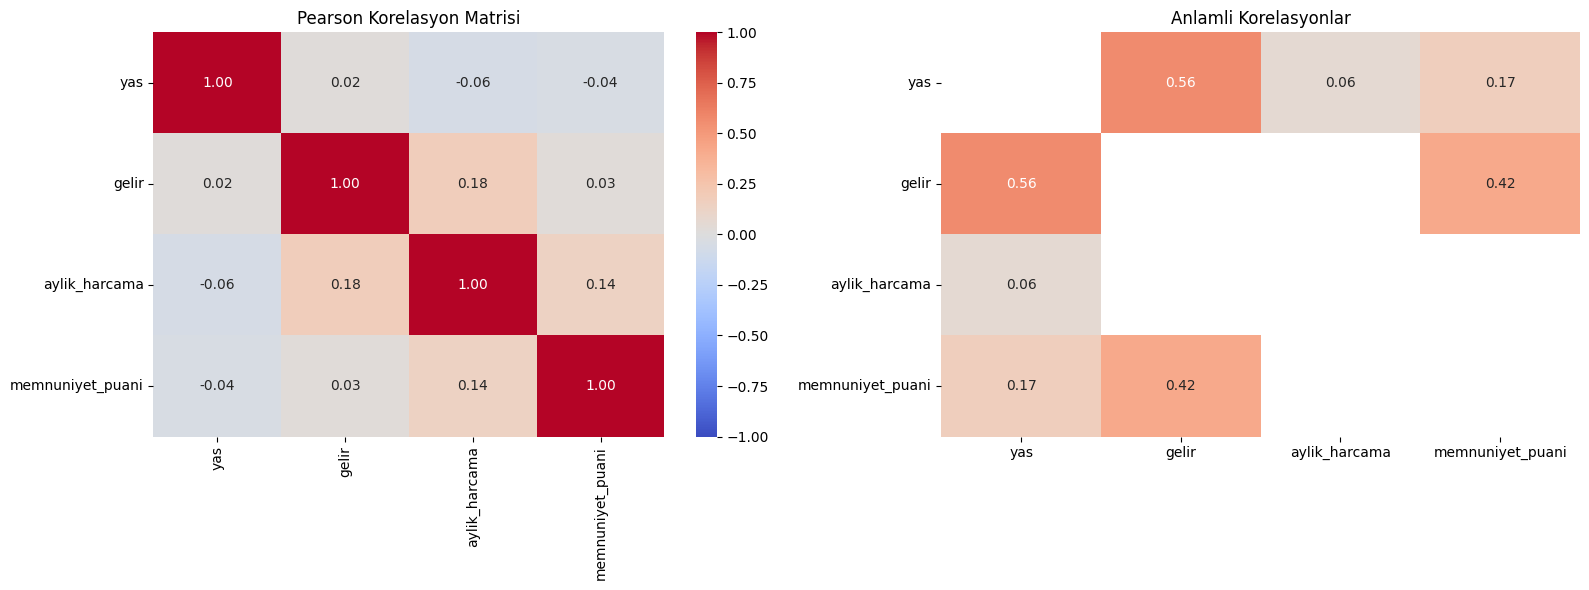

In [ ]:
fig , axes = plt.subplots(1,2, figsize=(16,6))
sns.heatmap(pearson_r,annot=True,fmt=".2f",cmap="coolwarm",center=0,vmin=-1,vmax=1,ax=axes[0])
axes[0].set_title("Pearson Korelasyon Matrisi")

anlamli_maske = pearson_p > 0.05

sns.heatmap(pearson_p,annot=True,fmt=".2f",cmap="coolwarm",center=0,vmin=-1,vmax=1,mask=~anlamli_maske,ax=axes[1],cbar=False)
axes[1].set_title("Anlamli Korelasyonlar")
plt.tight_layout()
plt.show()

## **Çoklu Doğrusal Bağlantı(Multicollinerity)**


* VIF < 5 sorun yok rahatız

* 5 <VIF<10 dikkat

* VIF>10 yandı gülüm keten helva o değişkenlerle o iş olmaz

In [ ]:
X_vif = df[["yas","gelir","memnuniyet_puani"]].dropna()
X_vif = sm.add_constant(X_vif)
vif_tablosu = pd.DataFrame({
    "Değişken":X_vif.columns,
    "VIF":[VIF(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_tablosu)   # 1 yerine 0 dan başlattık



           Değişken       VIF
0             const  1.000000
1               yas  1.002183
2             gelir  1.001182
3  memnuniyet_puani  1.002556


In [ ]:
X_vif = df[["yas", "gelir", "memnuniyet_puani"]].dropna()
X_vif_const = sm.add_constant(X_vif)

vif_tablosu = pd.DataFrame({
    "Değişken": X_vif.columns,
    "VIF": [VIF(X_vif_const.values, i) for i in range(1, X_vif_const.shape[1])]
})
print(vif_tablosu) # 0 index sabit değer çokta önemli değil onu yoksalım


           Değişken       VIF
0               yas  1.002183
1             gelir  1.001182
2  memnuniyet_puani  1.002556


In [ ]:
X_vif = df[["yas", "gelir", "memnuniyet_puani"]].dropna()
X_vif = sm.add_constant(X_vif)

vif_tablosu = pd.DataFrame({
    "Değişken": [X_vif.columns[i]for i in range(1, X_vif.shape[1])],
    "VIF": [VIF(X_vif.values, i) for i in range(1, X_vif.shape[1])]
})
print(vif_tablosu)

# 4 değişken var  ilk indeksimizide 0 'dan 1 e çekelim


           Değişken       VIF
0               yas  1.002183
1             gelir  1.001182
2  memnuniyet_puani  1.002556


# **Keşifci Regresyon**

In [ ]:
model_verisi = df[["aylik_harcama","gelir","memnuniyet_puani"]].dropna()
model_verisi = sm.add_constant(model_verisi)
model = smf.ols(formula="aylik_harcama~gelir+memnuniyet_puani",data=model_verisi)
sonuc = model.fit()
print(sonuc.summary())

                            OLS Regression Results                            
Dep. Variable:          aylik_harcama   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     22.85
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.05e-10
Time:                        12:32:57   Log-Likelihood:                -5838.4
No. Observations:                 926   AIC:                         1.168e+04
Df Residuals:                     923   BIC:                         1.170e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          161.2513     15.449  

## Temel Bileşenler Analizi(PCA)


In [ ]:
pca_verisi = df[sayisal_sutunlar].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_verisi)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
acıklanan_varyans = pca.explained_variance_ratio_
print(acıklanan_varyans)


[0.31181219 0.25684172 0.23593071 0.19541538]
